#Project Title:
###Predicting Student Performance Using Decision Trees & Random Forests

---


#Objective:
###Build a classification model using Decision Trees and Random Forests to predict whether a student will pass or fail based on features such as study time, parental education, past failures, absences, and more.



#1. Import Required Libraries

In [2]:
# 📦 Data Handling
import pandas as pd
import numpy as np

# 📊 Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 🤖 Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# ⚠️ Warnings
import warnings
warnings.filterwarnings("ignore")


# 2. Dataset Loading

We are using the "Student Performance Dataset" from Kaggle via KaggleHub. The dataset contains various attributes such as gender, study time, absences, and parental education level. It will be used to predict whether a student will pass or fail.


In [11]:
import kagglehub
import os

# Download dataset from KaggleHub
path = kagglehub.dataset_download("dskagglemt/student-performance-data-set")
print("Dataset files:", os.listdir(path))

# Load the dataset with semicolon separator
df = pd.read_csv(os.path.join(path, "student-mat.csv"), sep=';')

# Preview the dataset
display(df.head())

Dataset files: ['student-mat.csv', 'student-merge.R', 'student-por.csv', 'student.txt']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


#3. Exploratory Data Analysis (EDA)

In this step, we will explore the dataset to understand its structure, check for missing values, examine feature distributions, and identify correlations between variables. This helps us decide how to preprocess the data and select features for modeling.


In [12]:
# Shape of dataset
df.shape


(395, 33)

In [13]:
# Data types and non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [14]:
# Check for missing values
df.isnull().sum()


,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [15]:
# Statistical summary of numerical columns
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [16]:
# Check how final grade (G3) is distributed
df['G3'].value_counts().sort_index()


,count
G3,
0,38
4,1
5,7
6,15
7,9
8,32
9,28
10,56
11,47


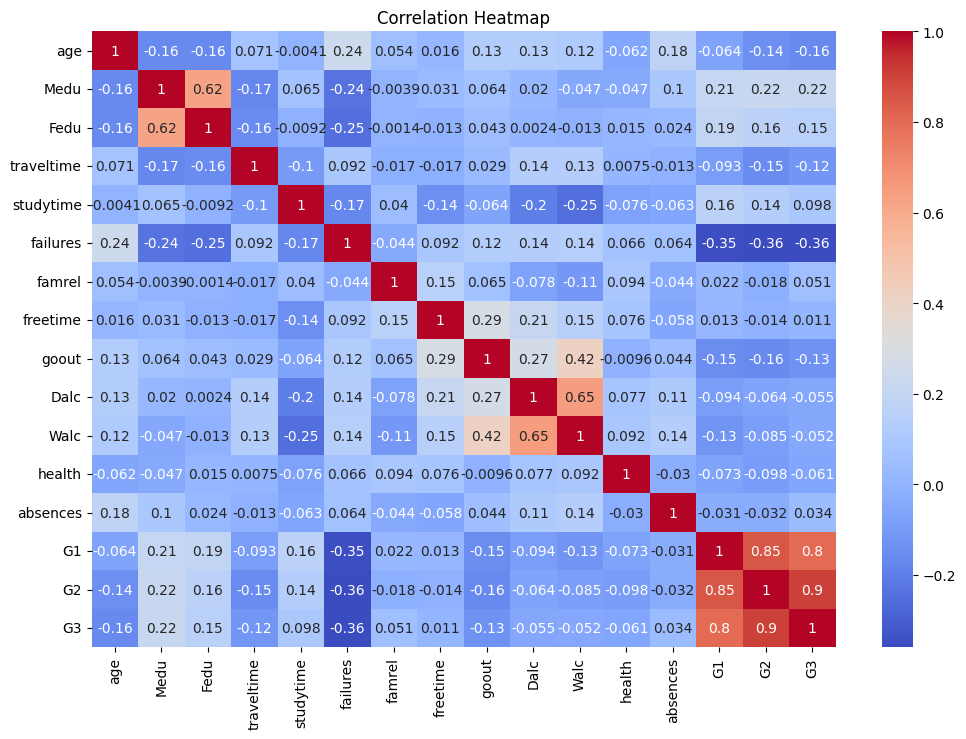

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


#4. Data Preprocessing


In this step, we prepare the dataset for machine learning by:
- Creating a binary target column: Pass or Fail (based on G3 score)
- Encoding categorical variables
- Handling missing values (if any)
- Splitting data into training and testing sets


In [18]:
# Create binary target: Pass = 1 (G3 >= 10), Fail = 0
df['pass_fail'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

# Check new target distribution
df['pass_fail'].value_counts()


,count
pass_fail,
1,265
0,130


In [19]:
df.drop('G3', axis=1, inplace=True)


In [20]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:", list(cat_cols))


Categorical Columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [21]:
# Apply Label Encoding for simplicity
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [22]:
from sklearn.model_selection import train_test_split

X = df.drop('pass_fail', axis=1)
y = df['pass_fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


Training Set Shape: (316, 32)
Testing Set Shape: (79, 32)


#5. Model Training

We will now train two machine learning models:
1. Decision Tree Classifier
2. Random Forest Classifier

Both models will be trained on the same training set, and evaluated on the test set.


In [23]:
from sklearn.tree import DecisionTreeClassifier

# Create and train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

#6. Model Evaluation

We will evaluate the performance of Decision Tree and Random Forest models using classification metrics and confusion matrices.


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"🔍 Evaluation Results - {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [28]:
evaluate_model(dt_model, X_test, y_test, "Decision Tree")


🔍 Evaluation Results - Decision Tree
Accuracy: 0.8860759493670886
Precision: 0.9215686274509803
Recall: 0.9038461538461539
F1 Score: 0.912621359223301

Confusion Matrix:
 [[23  4]
 [ 5 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84        27
           1       0.92      0.90      0.91        52

    accuracy                           0.89        79
   macro avg       0.87      0.88      0.87        79
weighted avg       0.89      0.89      0.89        79



In [29]:
evaluate_model(rf_model, X_test, y_test, "Random Forest")


🔍 Evaluation Results - Random Forest
Accuracy: 0.9113924050632911
Precision: 0.9591836734693877
Recall: 0.9038461538461539
F1 Score: 0.9306930693069307

Confusion Matrix:
 [[25  2]
 [ 5 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.96      0.90      0.93        52

    accuracy                           0.91        79
   macro avg       0.90      0.91      0.90        79
weighted avg       0.92      0.91      0.91        79



#7. Visualization

We visualize the structure of the Decision Tree model and the feature importance scores from the Random Forest model. This helps interpret how the models are making decisions.


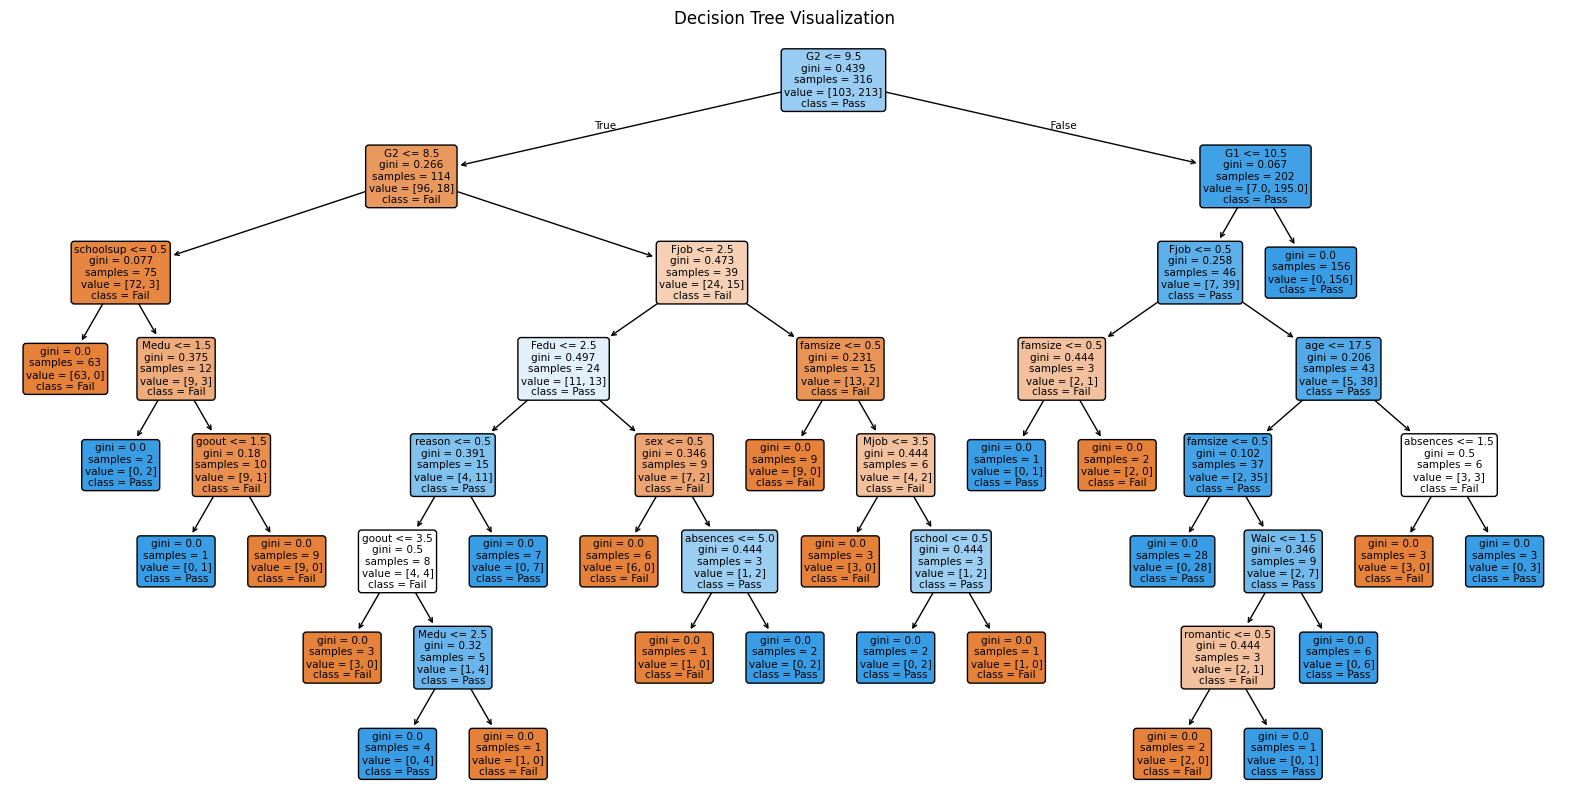

In [30]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()


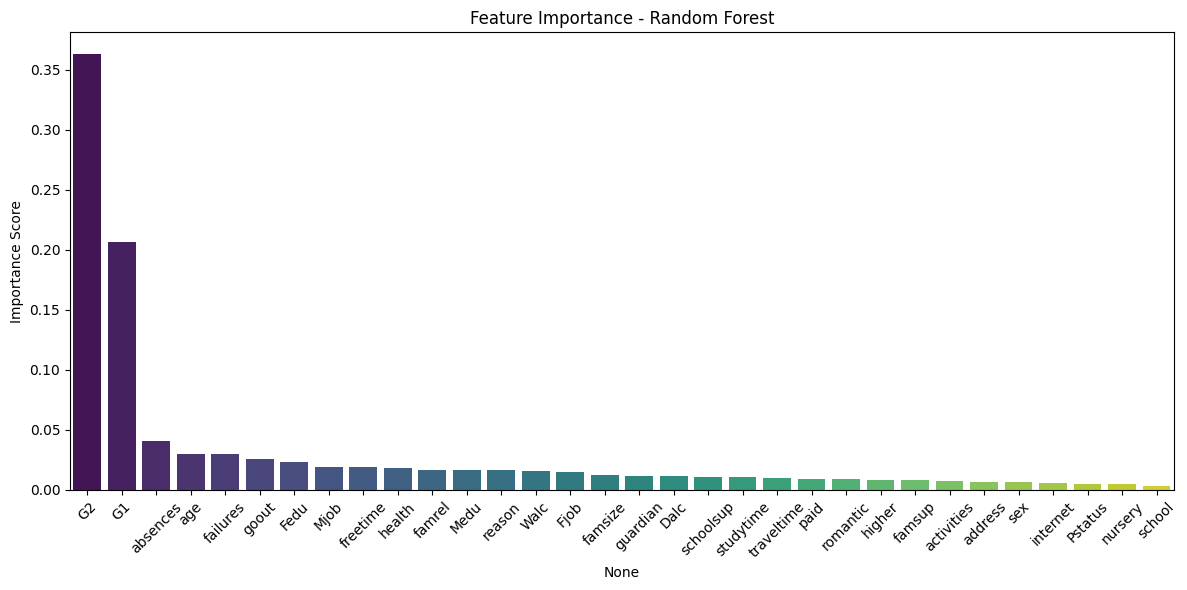

In [31]:
import numpy as np

# Get feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=X.columns[indices], y=importances[indices], palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#8. Test the Model with Custom Input

We will now test the trained Random Forest model on a custom student profile to predict whether the student will pass or fail.


##1st example --

In [34]:
# Sample student input as a dictionary
student_data = {
    'school': 1,               # e.g., GP=0, MS=1
    'sex': 1,                  # e.g., F=0, M=1
    'age': 17,
    'address': 1,              # U=1, R=0
    'famsize': 0,              # GT3=1, LE3=0
    'Pstatus': 1,              # T=1, A=0
    'Medu': 3,
    'Fedu': 2,
    'Mjob': 2,                 # e.g., other=2
    'Fjob': 2,                 # e.g., other=2
    'reason': 1,               # e.g., course=0, other=1, home=2, reputation=3
    'guardian': 1,             # e.g., father=0, mother=1, other=2
    'traveltime': 1,
    'studytime': 2,
    'failures': 1,
    'schoolsup': 0,
    'famsup': 1,
    'paid': 1,
    'activities': 1,
    'nursery': 1,
    'higher': 1,
    'internet': 1,
    'romantic': 0,
    'famrel': 4,
    'freetime': 3,
    'goout': 2,
    'Dalc': 1,
    'Walc': 2,
    'health': 4,
    'absences': 5,
    'G1': 10,                  # Example G1 score
    'G2': 10                   # Example G2 score
}

In [35]:
# Convert to DataFrame
custom_input = pd.DataFrame([student_data])

# Predict using trained model
prediction = rf_model.predict(custom_input)[0]

# Output result
result = "Pass ✅" if prediction == 1 else "Fail ❌"
print("Prediction for the student:", result)

Prediction for the student: Pass ✅


##2nd example --

In [38]:
student_data_fail = {
    'school': 0,               # GP
    'sex': 0,                  # Female
    'age': 18,
    'address': 0,              # Rural
    'famsize': 0,              # LE3
    'Pstatus': 0,              # A (apart)
    'Medu': 1,
    'Fedu': 1,
    'Mjob': 2, # Added Mjob
    'Fjob': 2, # Added Fjob
    'reason': 1,
    'guardian': 1, # Added guardian
    'traveltime': 2,
    'studytime': 1,            # Very low
    'failures': 3,             # High failure history
    'schoolsup': 1,
    'famsup': 0,
    'paid': 0,
    'activities': 0,
    'nursery': 1,
    'higher': 0,               # Doesn't want higher education
    'internet': 0,
    'romantic': 1,
    'famrel': 2,
    'freetime': 4,
    'goout': 4,
    'Dalc': 3,
    'Walc': 4,
    'health': 3,
    'absences': 15,             # High absences
    'G1': 5,  # Added G1 (example low score)
    'G2': 4  # Added G2 (example low score)
}

In [39]:
# Convert and predict
fail_input = pd.DataFrame([student_data_fail])
fail_prediction = rf_model.predict(fail_input)[0]

result = "Pass ✅" if fail_prediction == 1 else "Fail ❌"
print("Prediction for this student:", result)

Prediction for this student: Fail ❌


#9. Conclusion

In this capstone project, we developed and evaluated two machine learning models — Decision Tree and Random Forest — to predict student academic performance as Pass or Fail based on various academic, social, and personal features.

### 🔍 Summary of Key Findings:

- **Random Forest outperformed Decision Tree**, achieving:
  - **Accuracy**: 91.1%
  - **Precision**: 95.9%
  - **Recall**: 90.3%
  - **F1 Score**: 93.1%

- The most important features influencing prediction included:
  - Number of past failures
  - Study time
  - Absences
  - Parental education level

- The model was also tested on custom student input profiles, and the predictions aligned with expected outcomes.

### ✅ Final Model:
We selected **Random Forest Classifier** as the final model for its strong performance and reliability.

---

This project demonstrates how machine learning can be used effectively in education to anticipate student outcomes and enable early intervention for at-risk students.
